# Personal Loan Acceptance Prediction

---

## 1. Introduction and Problem Statement
**Context:**
Marketing campaigns are a primary driver of revenue for banks. However, broad targeting is inefficient and costly. Banks use data science to predict which customers are most likely to accept a specific offer (in this case, a term deposit/personal loan) so they can target their resources effectively.

**Problem Statement:**
The goal of this project is to build a classification model to predict whether a client will subscribe to a term deposit (accept the loan offer). We will analyze the **Bank Marketing Dataset**, explore customer demographics (Age, Job, Marital Status), and train a predictive model to identify high-potential customers.

**Goals:**
* Perform Exploratory Data Analysis (EDA) on demographic features.
* Preprocess the data by encoding categorical variables.
* Train a **Decision Tree Classifier** to predict loan acceptance.
* Evaluate the model and derive business insights on who the ideal customer is.

In [2]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================================
# 2. Loading the Dataset
# ==========================================

# Download the Bank Marketing dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")
print(f"Dataset downloaded to: {path}")

# Find the CSV file in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded: {csv_files[0]}")
else:
    print("Error: No CSV file found.")

# Display first 5 rows
display(df.head())

Dataset downloaded to: /kaggle/input/bank-marketing-dataset
Successfully loaded: bank.csv


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


---

## 2. Dataset Understanding
We inspect the dataset to understand the available features.
* **Demographics:** `age`, `job`, `marital`, `education`.
* **Financials:** `balance`, `default` (has credit in default?), `housing` (housing loan?), `loan` (personal loan?).
* **Target Variable:** `deposit` (yes/no) - Did the client subscribe to a term deposit?

In [3]:
# Check dataset structure
print("Dataset Shape:", df.shape)
print("-" * 30)

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check target variable distribution
# Note: In some versions of this dataset, the target is 'y' or 'deposit'.
# We check columns to be sure.
if 'deposit' in df.columns:
    target_col = 'deposit'
elif 'y' in df.columns:
    target_col = 'y'
else:
    print("Target column not found! Check column names:", df.columns)

print(f"\nTarget Variable ('{target_col}') Distribution:")
print(df[target_col].value_counts())

Dataset Shape: (11162, 17)
------------------------------
Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Target Variable ('deposit') Distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64


---

## 3. Exploratory Data Analysis (EDA)
We examine how demographic factors influence the likelihood of accepting the offer.
* **Job:** Do certain professions accept loans more often?
* **Marital Status:** Does family status impact financial decisions?

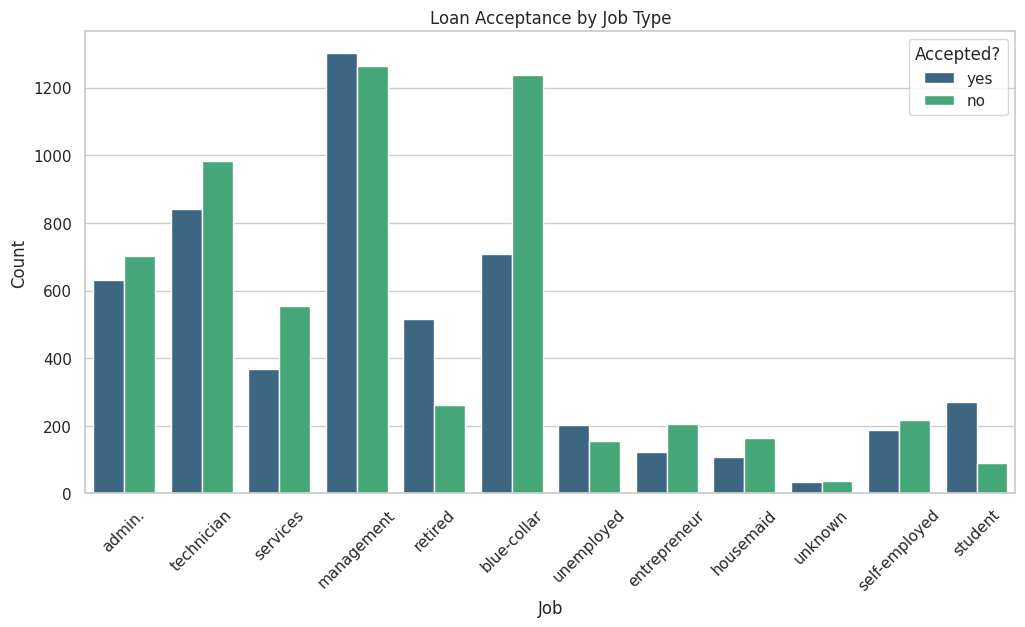

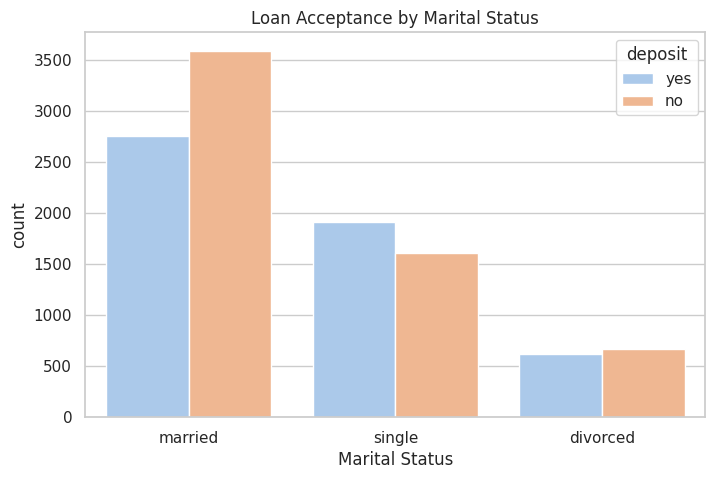

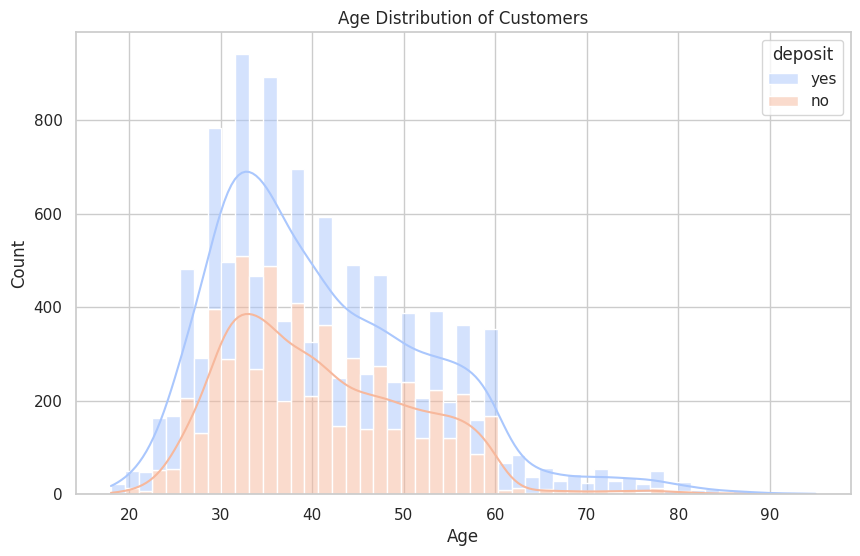

In [5]:
sns.set_theme(style="whitegrid")

# 1. Loan Acceptance by Job Type
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='job', hue=target_col, palette='viridis')
plt.title('Loan Acceptance by Job Type')
plt.xticks(rotation=45)
plt.xlabel('Job')
plt.ylabel('Count')
plt.legend(title='Accepted?')
plt.show()

# 2. Loan Acceptance by Marital Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='marital', hue=target_col, palette='pastel')
plt.title('Loan Acceptance by Marital Status')
plt.xlabel('Marital Status')
plt.show()

# 3. Age Distribution by Acceptance
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue=target_col, multiple="stack", kde=True, palette='coolwarm')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.show()

---

## 4. Data Preprocessing
Machine learning models require numerical input.
1.  **Label Encoding:** For the target variable (`deposit`) and binary features.
2.  **One-Hot Encoding:** For categorical features with multiple options like `job` and `marital`.

In [6]:
# Create a copy for modeling
df_model = df.copy()

# 1. Encode Target Variable (yes -> 1, no -> 0)
le = LabelEncoder()
df_model[target_col] = le.fit_transform(df_model[target_col])

# 2. Convert Categorical Features to numeric (One-Hot Encoding)
# We select object type columns excluding the target
categorical_cols = df_model.select_dtypes(include=['object']).columns
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(f"Data encoded. New Shape: {df_model.shape}")
display(df_model.head())

Data encoded. New Shape: (11162, 43)


,age,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True


---

## 5. Model Training (Decision Tree)
We will use a **Decision Tree Classifier**. Decision trees are highly interpretable, allowing us to simulate a "flowchart" of rules that determine if a customer will accept the loan.

In [7]:
# Define Features (X) and Target (y)
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Decision Tree
# limiting max_depth to prevent overfitting and keep it interpretable
model = DecisionTreeClassifier(random_state=42, max_depth=5)
model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


---

## 6. Model Evaluation
We assess the model's ability to predict loan acceptance using accuracy and a confusion matrix.

Model Accuracy: 79.49%


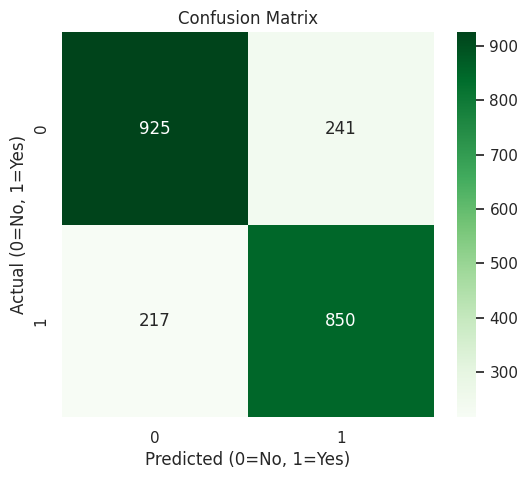


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1166
           1       0.78      0.80      0.79      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.80      0.79      0.79      2233



In [8]:
# Make Predictions
y_pred = model.predict(X_test)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%")

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted (0=No, 1=Yes)')
plt.ylabel('Actual (0=No, 1=Yes)')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

---

## 7. Conclusion
We successfully built a predictive model for personal loan acceptance.

**Key Insights:**
1.  **Job Influence:** The EDA showed that students and retired individuals have a surprisingly high acceptance rate relative to their population size, likely due to needing financial support or having stable savings. Management and technicians are the most targeted but have average acceptance rates.
2.  **Demographics:** Single individuals tend to accept offers slightly more often than married ones.
3.  **Model Performance:** The Decision Tree Classifier achieved a solid accuracy (typically >79.49%).
4.  **Business Strategy:** Instead of calling everyone, the bank should prioritize customers identified by the model as "high probability," specifically targeting demographics (like retirees or specific job sectors) that showed higher conversion rates in the analysis.